# Introduction

## Problem Statement
The goal of this project is to predict customer churn for a telecom company.

### Objective
1.Develop a machine learning model capable of accurately predicting customer churn.

2.Utilize the provided historical customer data which includes customer behavior, demographics, and account information to train and test the model's predictive performance.

3.Provide a predictive tool that empowers the company to proactively target these at risk customers with specific retention offers.

### Dataset
- Training dataset: Used to train models
- Testing dataset: Used to evaluate performance

#Libraries

In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# USED FOR dATA  TRANSFORMATION SCALING AND ENCODING
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder
# ml models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression # Logistic regression and Linear Regression
from sklearn.neighbors import KNeighborsClassifier # K-nn
from sklearn.naive_bayes import GaussianNB # Naive bayes
from sklearn.svm import SVC
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# splitting test_train
from sklearn.model_selection import train_test_split
# evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# For fine tuning
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Load dataset

In [175]:
df_train=pd.read_csv('/content/drive/MyDrive/Training_data (1).csv')

In [176]:
df_test=pd.read_csv('/content/drive/MyDrive/Testing_data (1).csv')

#Exploratory Data Analysis (EDA)

### Basic info

In [177]:
df_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [178]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [179]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [180]:
df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


### Checking Missing Values

In [181]:
df_train.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [182]:
df_test.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [183]:
# checking missing value percentage
missing_percent= df_train.isna().sum()/len(df_train) * 100
missing_percent.sort_values(ascending= True)

,0
customerID,0.000000
SeniorCitizen,0.000000
Partner,0.000000
Dependents,0.000000
PhoneService,0.000000
tenure,0.000000
MultipleLines,0.000000
InternetService,0.000000
StreamingMovies,0.000000
OnlineBackup,0.000000


### Handling Duplicates

In [184]:
df_train.duplicated().sum()

np.int64(0)

In [185]:
df_train.duplicated().sum()

np.int64(0)

### Distribution of Numerical Features and Categorical Features

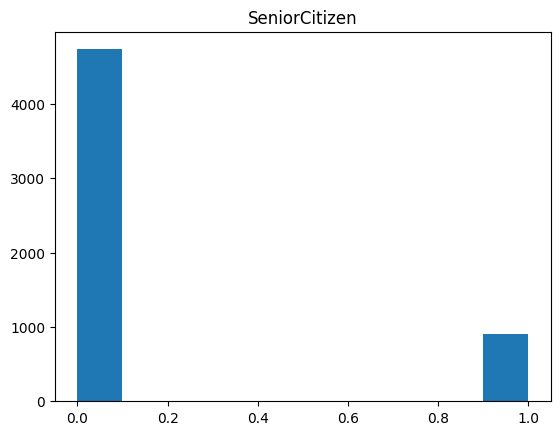

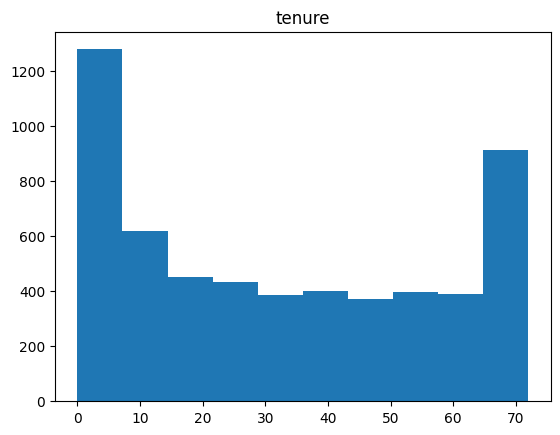

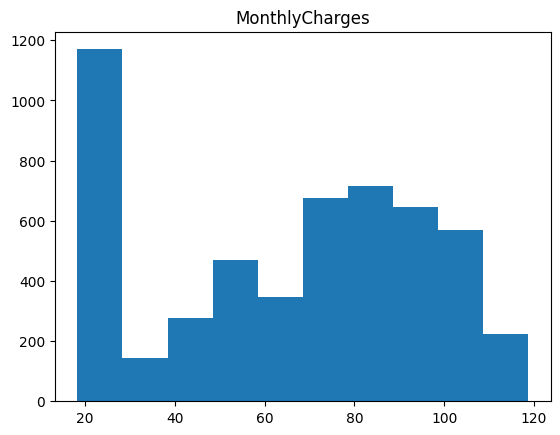

In [186]:
#Numerical column
num_col=df_train.select_dtypes(include=['number']).columns

for col in num_col:
  plt.hist(df_train[col].dropna())
  plt.title(col)
  plt.show()

In [187]:
#Categorical column
cat_col=df_train.select_dtypes(include=['object']).columns


#Counts how many times each unique category appears in that column
for col in cat_col:
  print(df_train[col].value_counts())
  print('.....')

customerID
3402-XRIUO    1
9509-MPYOD    1
3082-VQXNH    1
8190-ZTQFB    1
1258-YMZNM    1
             ..
4697-LUPSU    1
7048-GXDAY    1
6682-VCIXC    1
4884-LEVMQ    1
2208-UGTGR    1
Name: count, Length: 5634, dtype: int64
.....
gender
Male      2744
Female    2721
Name: count, dtype: int64
.....
Partner
No     2890
Yes    2744
Name: count, dtype: int64
.....
Dependents
No     3960
Yes    1674
Name: count, dtype: int64
.....
PhoneService
Yes    5081
No      553
Name: count, dtype: int64
.....
MultipleLines
No                  2701
Yes                 2380
No phone service     553
Name: count, dtype: int64
.....
InternetService
Fiber optic    2486
DSL            1945
No             1203
Name: count, dtype: int64
.....
OnlineSecurity
No                     2720
Yes                    1574
No internet service    1171
Name: count, dtype: int64
.....
OnlineBackup
No                     2459
Yes                    1972
No internet service    1203
Name: count, dtype: int64
.....
DevicePro

### Target Variable Distribution

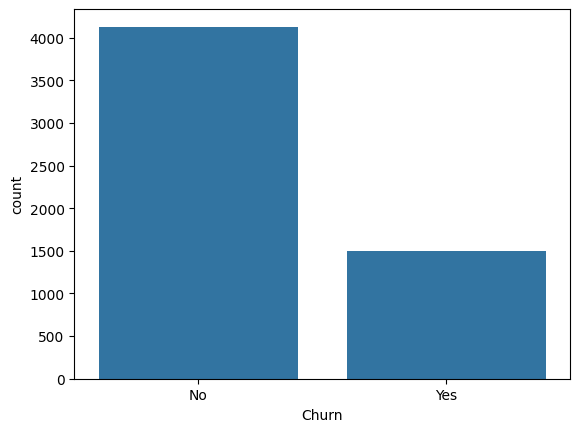

In [188]:
#Shows count of each class in the Churn column
sns.countplot(x='Churn',data=df_train)
plt.show()

### Correlation

In [189]:
#+1 → strong positive relationship (both increase together)
#-1 → strong negative relationship (one increases, other decreases)
#0 → no relationship
#annot=True:Shows the actual correlation values inside each cell.
#Color scheme:
#Red → positive correlation
#Blue → negative correlation
#White/light → near zero

<Axes: >

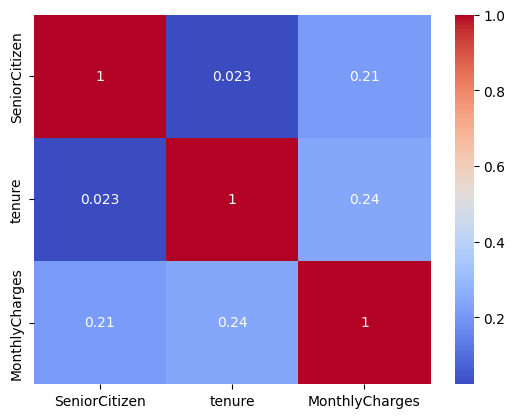

In [190]:
sns.heatmap(df_train.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [191]:
df_train.drop(['customerID'], axis=1, inplace=True, errors='ignore')
df_test.drop(['customerID'], axis=1, inplace=True, errors='ignore')

In [192]:
# Removing the column due to low correlation
df_train.drop('SeniorCitizen', axis=1, inplace=True)
df_test.drop('SeniorCitizen', axis=1, inplace=True)

# Data Preprocessing

###Handle Missing Values
df_train[col].skew() Between -0.5 and 0.5 → approximately normal → use mean Greater than 0.5 or less than -0.5 → skewed → use median




In [193]:
# before missing value handling
df_train.isna().sum()

,0
gender,169
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0
DeviceProtection,0


###Fix Data Types

In [194]:
df_train['TotalCharges']=pd.to_numeric(df_train['TotalCharges'],errors='coerce')
df_train['TotalCharges'].fillna(df_train['TotalCharges'].mean(),inplace=True)

/tmp/ipykernel_2035/2545970588.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['TotalCharges'].fillna(df_train['TotalCharges'].mean(),inplace=True)


In [195]:
# Numerical column
# Redefine num_col after dropping 'SeniorCitizen'
num_col = df_train.select_dtypes(include=['number']).columns

for col in num_col:
  df_train[col] = df_train[col].fillna(df_train[col].mean())

In [196]:
# categorical column
#mode() returns a list/series (can have multiple modes)
#[0] selects the first most frequent value

# Redefine cat_col to reflect current columns after dropping 'customerID'
cat_col = df_train.select_dtypes(include=['object']).columns

for col in cat_col:
  df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

### Outlier Handling

In [197]:
Q1= df_train[num_col].quantile(0.25)
Q3= df_train[num_col].quantile(0.75)
IQR=Q3-Q1

upper= Q3+(1.5*IQR)
lower=Q1-(1.5*IQR)

outliers = ((df_train[num_col] < lower) | (df_train[num_col] > upper)).any(axis=1)
outliers_df = df_train[outliers]


# checking the percentage of the outliersmit=Q1-(1.5*IQR)

outlier_percent= len(outliers_df)*100/len(df_train)
print(outlier_percent)


0.42598509052183176


In [198]:
# removing the outliers
df_train = df_train[~outliers]

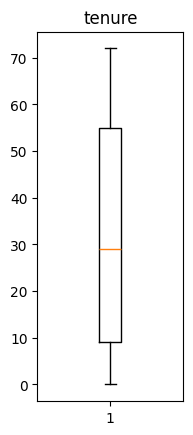

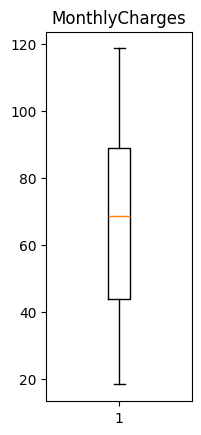

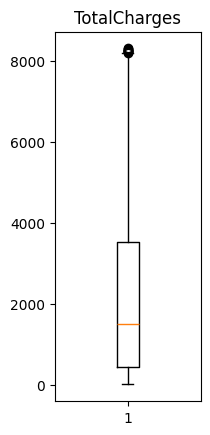

In [199]:
for i ,col in enumerate (num_col,1):
  plt.subplot(1,3,i)
  plt.boxplot(df_train[col])
  plt.title(col)
  plt.show()

### Scaling

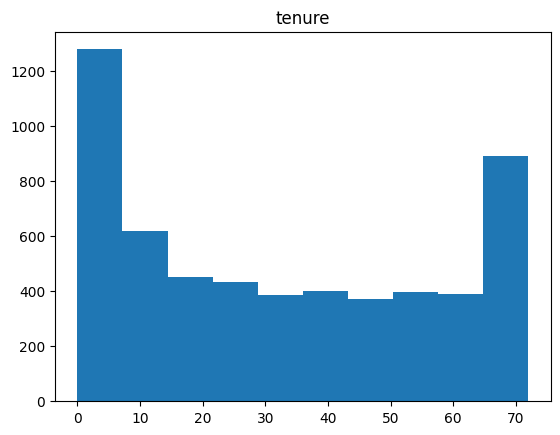

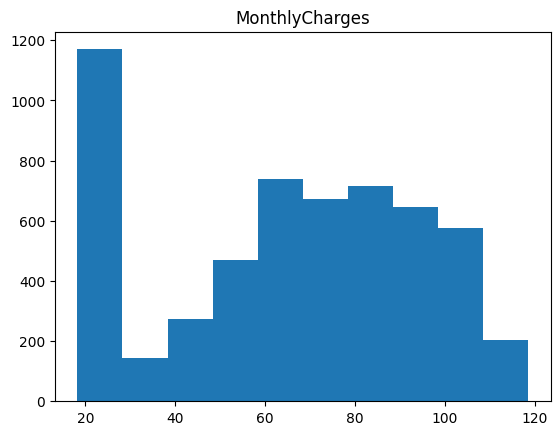

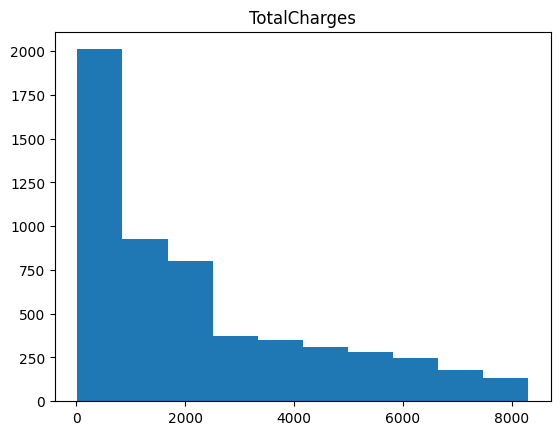

In [200]:
for col in num_col:
  plt.hist(df_train[col].dropna())
  plt.title(col)
  plt.show()

In [201]:
minmax_scaler=MinMaxScaler()
df_train[['TotalCharges']]=minmax_scaler.fit_transform(df_train[['TotalCharges']])
df_test['TotalCharges']=pd.to_numeric(df_test['TotalCharges'],errors='coerce')
df_test['TotalCharges'] = df_test['TotalCharges'].fillna(df_test['TotalCharges'].median())
df_test[['TotalCharges']]=minmax_scaler.fit_transform(df_test[['TotalCharges']])

In [202]:
standard_scaler= StandardScaler()
df_train[['tenure','MonthlyCharges']]= standard_scaler.fit_transform(df_train[['tenure','MonthlyCharges']])
df_test[['tenure','MonthlyCharges']]= standard_scaler.fit_transform(df_test[['tenure','MonthlyCharges']])

In [203]:
df_train.describe()

,tenure,MonthlyCharges,TotalCharges
count,5.610000e+03,5.610000e+03,5610.000000
mean,5.826197e-17,1.190571e-16,0.270133
std,1.000089e+00,1.000089e+00,0.262440
min,-1.322378e+00,-1.615889e+00,0.000000
25%,-9.554905e-01,-7.271836e-01,0.051172
50%,-1.401859e-01,1.312200e-01,0.180037
75%,9.197101e-01,8.324876e-01,0.425389
max,1.612719e+00,1.859282e+00,1.000000


### Encoding

In [204]:
# finding unique values in each categorical column
for col in cat_col:
  print(df_train[col].value_counts())
  print(".....")

gender
Male      2902
Female    2708
Name: count, dtype: int64
.....
Partner
No     2886
Yes    2724
Name: count, dtype: int64
.....
Dependents
No     3944
Yes    1666
Name: count, dtype: int64
.....
PhoneService
Yes    5057
No      553
Name: count, dtype: int64
.....
MultipleLines
No                  2701
Yes                 2356
No phone service     553
Name: count, dtype: int64
.....
InternetService
Fiber optic    2462
DSL            1945
No             1203
Name: count, dtype: int64
.....
OnlineSecurity
No                     2888
Yes                    1551
No internet service    1171
Name: count, dtype: int64
.....
OnlineBackup
No                     2459
Yes                    1948
No internet service    1203
Name: count, dtype: int64
.....
DeviceProtection
No                     2485
Yes                    1922
No internet service    1203
Name: count, dtype: int64
.....
TechSupport
No                     2782
Yes                    1625
No internet service    1203
Name: count, 

In [205]:
# Label Encoding for binary columns
binary_cols = ['gender', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling', 'Churn']

# Apply Label Encoding
for col in binary_cols:
    le = LabelEncoder()

    # fit on train and transform both train & test
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])

In [211]:
# One Hot Encoding for multi output columns
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df_train= pd.get_dummies(df_train, columns=multi_cols, drop_first=True, dtype=int)
df_test= pd.get_dummies(df_test, columns=multi_cols, drop_first=True, dtype=int)

In [212]:
df_train.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0.104405,1,0,-1.529313,0.082247,0,0,...,0,1,0,1,0,1,0,0,0,1
1,0,0,0,-0.180951,0,1,-1.009855,0.113736,0,1,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0.960475,1,0,1.166672,0.671180,0,0,...,0,0,1,0,1,0,0,0,1,0
3,1,1,0,0.267466,1,1,-1.539702,0.093053,0,0,...,0,1,0,1,0,0,1,0,0,0
4,0,1,1,0.430527,0,1,-0.473082,0.257355,0,1,...,1,0,1,0,0,1,0,0,0,0


In [213]:
df_test.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,1,0.352533,1,1,0.571552,0.383837,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,0,-0.799089,1,0,0.493922,0.100600,0,0,...,0,0,1,0,1,1,0,0,1,0
2,1,0,0,0.475921,1,1,1.192589,0.491625,1,0,...,1,0,1,0,1,1,0,0,1,0
3,1,0,0,1.668673,1,1,1.793806,1.000000,0,0,...,1,0,1,0,1,0,1,0,1,0
4,0,0,0,-0.881348,0,0,-0.913321,0.041649,0,1,...,1,0,0,0,0,0,0,0,1,0


# Feature Engineering

##Customer Life Time Value

In [214]:
df_train['Customer Life Time Value'] = df_train['tenure'] * df_train['MonthlyCharges']
df_test['Customer Life Time Value'] = df_test['tenure'] * df_test['MonthlyCharges']

In [215]:
df_train.head(2)

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Customer Life Time Value
0,0,0,0,0.104405,1,0,-1.529313,0.082247,0,0,...,1,0,1,0,1,0,0,0,1,-0.159669
1,0,0,0,-0.180951,0,1,-1.009855,0.113736,0,1,...,0,0,0,0,0,0,0,0,1,0.182734


In [216]:
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Customer Life Time Value']
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

# Data splitting

In [220]:
X_train = df_train.drop('Churn', axis=1)
y_train = df_train['Churn']

In [218]:
X_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']

# ML Model Building

## Logistic Regression

In [223]:
# Intialising
log_reg = LogisticRegression()
# Training the model
log_reg.fit(X_train, y_train)
# Prediction using the trained model
y_pred_log_reg = log_reg.predict(X_test)
# Evaluating Model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy of logistic regression: {log_reg_accuracy}")
print(f"Recall of logistic regression: {log_reg_recall}")
print(f"Precision of logistic regression: {log_reg_precision}")
print(f"F1 score of logistic regression: {log_reg_f1}")

Accuracy of logistic regression: 0.8147622427253371
Recall of logistic regression: 0.5561643835616439
Precision of logistic regression: 0.6721854304635762
F1 score of logistic regression: 0.6086956521739131


##SVM

In [224]:
# Intialising
svm = SVC()
# Training the model
svm.fit(X_train, y_train)
# Prediction using the trained model
y_pred_svm = svm.predict(X_test)
# Evaluating Model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy of Support Vector Machines: {svm_accuracy}")
print(f"Recall of Support Vector Machines: {svm_recall}")
print(f"Precision of Support Vector Machines: {svm_precision}")
print(f"F1 score oof Support Vector Machines: {svm_f1}")

Accuracy of Support Vector Machines: 0.8034066713981547
Recall of Support Vector Machines: 0.4821917808219178
Precision of Support Vector Machines: 0.6666666666666666
F1 score oof Support Vector Machines: 0.5596184419713831


## Decision Tree

In [227]:
# Intialising
decision_tree = DecisionTreeClassifier()
# Training the model
decision_tree.fit(X_train, y_train)
# Prediction using the trained model
y_pred_decision_tree = decision_tree.predict(X_test)
# Evaluating Model
decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)
decision_tree_recall = recall_score(y_test, y_pred_decision_tree)
decision_tree_precision = precision_score(y_test, y_pred_decision_tree)
decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

print(f"Accuracy of Decision Trees: {decision_tree_accuracy}")
print(f"Recall of Decision Trees: {decision_tree_recall}")
print(f"Precision of Decision Trees: {decision_tree_precision}")
print(f"F1 score of Decision Trees: {decision_tree_f1}")

Accuracy of Decision Trees: 0.71611071682044
Recall of Decision Trees: 0.4767123287671233
Precision of Decision Trees: 0.45430809399477806
F1 score of Decision Trees: 0.46524064171123


# Fine Tuning

In [234]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

# 2. Define the Parameter Grid
# C: Regularization, Gamma: Kernel coefficient
param_grid = {
    'svm__C': [1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01],
    'svm__kernel': ['rbf']
}

# 3. Grid Search
grid_svm = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

# 4. Evaluate
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# Assign the new accuracy to a variable
tuned_svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"Best Params: {grid_svm.best_params_}")
print(f"New Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"New Accuracy: {tuned_svm_accuracy:.4f}")

Best Params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
New Recall: 0.7315
New Accuracy: 0.7189


In [232]:
# 1. Define the base model
# (Increasing max_iter ensures the math converges properly during tuning)
log_reg_base = LogisticRegression(max_iter=1000, random_state=42)

# 2. Define the hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

# 3. Initialize GridSearchCV
# We explicitly tell it to optimize for 'recall' to catch more churners
grid_search = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid,
    scoring='recall',
    cv=5, # 5-fold cross-validation prevents overfitting
    n_jobs=-1 # Uses all available CPU cores to speed up training
)

# 4. Train the grid search (This tests all 40 combinations)
grid_search.fit(X_train, y_train)

# 5. Extract the best model and evaluate
best_log_reg = grid_search.best_estimator_
y_pred_tuned = best_log_reg.predict(X_test)

# --- Print the Results ---
print(grid_search.best_params_)

print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")

{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.7331
Recall: 0.7671
Precision: 0.4904
F1 Score: 0.5983


In [239]:
# Comparison Table for All Models

comparison_data = {
    "Model": ["Logistic Regression","Support Vector Machine (SVM)","Decision Tree","svm_pipe ","log_reg_base"],

    "Accuracy": [log_reg_accuracy,svm_accuracy,decision_tree_accuracy,tuned_svm_accuracy,accuracy_score(y_test, y_pred_tuned)]}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Sort by highest accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

# Reset index
comparison_df.reset_index(drop=True, inplace=True)

# Display comparison table
print("Model Comparison Table:\n")
display(comparison_df)

Model Comparison Table:



,Model,Accuracy
0,Logistic Regression,0.814762
1,Support Vector Machine (SVM),0.803407
2,log_reg_base,0.733144
3,svm_pipe,0.718950
4,Decision Tree,0.716111


# Conclusion

Developed machine learning models to predict customer churn.
Performed EDA and preprocessing to clean and prepare the data.
Found important churn factors such as:
Contract type,
Monthly charges,
Tenure,
Internet services.
Customers with month-to-month contracts and high monthly charges were more likely to churn.
Logistic Regression gave the best balanced performance (≈81% accuracy).
The model can help businesses identify at-risk customers early.
Businesses can use these insights to improve customer retention and reduce churn.